**1. Sales Prediction**

Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load dataset

In [3]:
df = pd.read_csv("/content/Advertising.csv")

Display first 5 rows

In [4]:
print(df.head())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


Create dataset information

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


Check for the missing values

In [6]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


Features and Target variable

In [7]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

Split the dataset

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train the model

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Model Prediction

In [10]:
y_pred = model.predict(X_test)

Evaluation

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Evaluation
-----------------
MAE : 1.4607567168117603
MSE : 3.1740973539761033
RMSE: 1.78159966153345
R2 Score: 0.899438024100912


Compare Actual vs Predicted

In [12]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print("\nActual vs Predicted")
print(comparison.head())


Actual vs Predicted
   Actual Sales  Predicted Sales
0          16.9        16.408024
1          22.4        20.889882
2          21.4        21.553843
3           7.3        10.608503
4          24.7        22.112373


Plot Actual vs Predicted

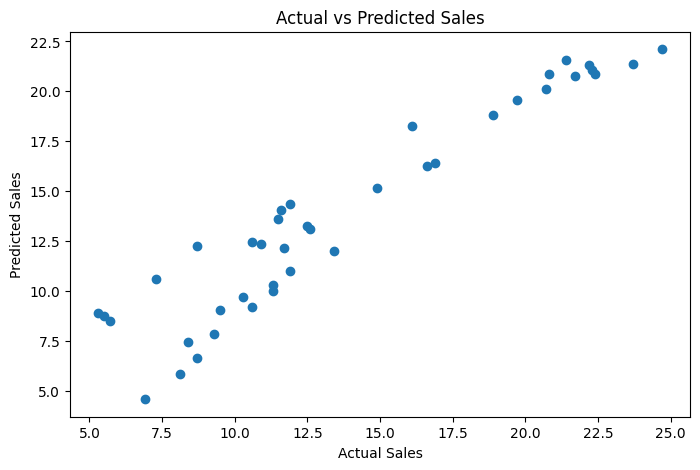

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

Predict New scales

In [14]:
new_data = pd.DataFrame({
    'TV': [230],
    'Radio': [37],
    'Newspaper': [69]
})

prediction = model.predict(new_data)

print("\nPredicted Sales:", prediction[0])


Predicted Sales: 20.45759025215365
